<a href="https://colab.research.google.com/github/Asmitx026/AI-Lab/blob/main/assignment_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Q1. Implement a Simple Perceptron

In [3]:
import numpy as np
from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score

In [ ]:
X = np.array([
    [1, 50],
    [2, 55],
    [3, 60],
    [5, 75],
    [6, 80],
    [7, 85]
])

y = np.array([0, 0, 0, 1, 1, 1])

In [ ]:
model = Perceptron(max_iter=1000, random_state=42)
model.fit(X, y)
y_pred = model.predict(X)
accuracy = accuracy_score(y, y_pred)

In [ ]:
print(f"Feature 1: {X[:, 0]}")
print(f"Feature 2: {X[:, 1]}")

print(f"\nActual Value: {y}")
print(f"Predicted Value: {y_pred}")

print(f"\nAccuracy: {accuracy}")
print(f"Weights: {model.coef_}")
print(f"Bias: {model.intercept_}")

Feature 1: [1 2 3 5 6 7]
Feature 2: [50 55 60 75 80 85]

Actual Value: [0 0 0 1 1 1]
Predicted Value: [0 0 0 0 0 0]

Accuracy: 0.5
Weights: [[ 38. -15.]]
Bias: [-6.]


In [ ]:
new_std = np.array([[4, 70]])
new_pred = model.predict(new_std)
if new_pred[0] == 1:
    print("The student will pass the exam.")
else:
    print("The student will fail the exam.")

The student will fail the exam.


### Q2. Implement a Preceptron with Decision Boundary

In [4]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

In [ ]:
model = make_pipeline(
    StandardScaler(),
    Perceptron(max_iter=1000, eta0=0.01, random_state=42)
)
model.fit(X, y)
y_pred = model.predict(X)
accuracy = accuracy_score(y, y_pred)

In [ ]:
print(f"Actual Value: {y}")
print(f"Predicted Value: {y_pred}\n")

new_std = np.array([[4, 70]])
new_pred = model.predict(new_std)
if new_pred[0] == 1:
    print("The student will pass the exam.")
else:
    print("The student will fail the exam.")

Actual Value: [0 0 0 1 1 1]
Predicted Value: [0 0 0 1 1 1]

The student will pass the exam.


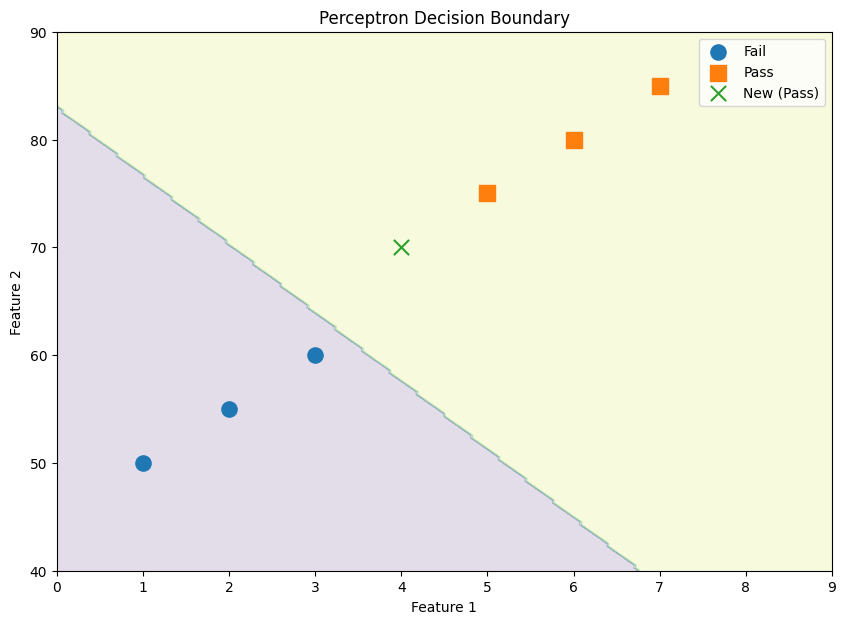

In [ ]:
x_min, x_max = 0, 9
y_min, y_max = 40, 90

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 200),
    np.linspace(y_min, y_max, 200)
)

grid = np.c_[xx.ravel(), yy.ravel()]

z= model.predict(grid)
z= z.reshape(xx.shape)

plt.figure(figsize=(10,7))
plt.contourf(xx,yy,z,alpha=0.15)
plt.scatter(X[y == 0,0], X[y == 0,1],marker='o',s=120, label='Fail')
plt.scatter(X[y == 1,0], X[y == 1,1],marker='s',s=120, label='Pass')
plt.scatter(new_std[0,0], new_std[0,1], marker='x', s=120, label='New (Pass)')
plt.legend()
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Perceptron Decision Boundary')
plt.show()

### Q3. Predict the result of students based on Study Hours and Attendance using KNN Algorithm

In [71]:
from sklearn.neighbors import KNeighborsClassifier
import seaborn as sns

In [22]:
X = np.array([
    [2, 55],
    [5, 75],
    [1, 50],
    [6, 80],
    [3, 60],
    [7, 85]
])

y = np.array([0,1,0,1,0,1])

In [23]:
k = 3
model = make_pipeline(
    StandardScaler(),
    KNeighborsClassifier(n_neighbors=k)
)
model.fit(X, y)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('kneighborsclassifier', KNeighborsClassifier(n_neighbors=3))])

In [24]:
X_scaled = model.named_steps['standardscaler'].transform(X)
print(X_scaled)

[[-0.9258201  -0.95058638]
 [ 0.46291005  0.57035183]
 [-1.38873015 -1.33082093]
 [ 0.9258201   0.95058638]
 [-0.46291005 -0.57035183]
 [ 1.38873015  1.33082093]]


In [28]:
new_X = np.array([[4,70]])
new_X_scaled = model.named_steps['standardscaler'].transform(new_X)
print(f"Scaled new_X: {new_X_scaled}")

if new_pred[0] == 1:
    print("The student will pass the exam.")
else:
    print("The student will fail the exam.")

Scaled new_X: [[0.         0.19011728]]
The student will pass the exam.


Nearest Neighbors:
Neighbor 1: X = [ 5 75], Class = 1, Distance = 0.5991
Neighbor 2: X = [ 3 60], Class = 0, Distance = 0.8903
Neighbor 3: X = [ 6 80], Class = 1, Distance = 1.1981




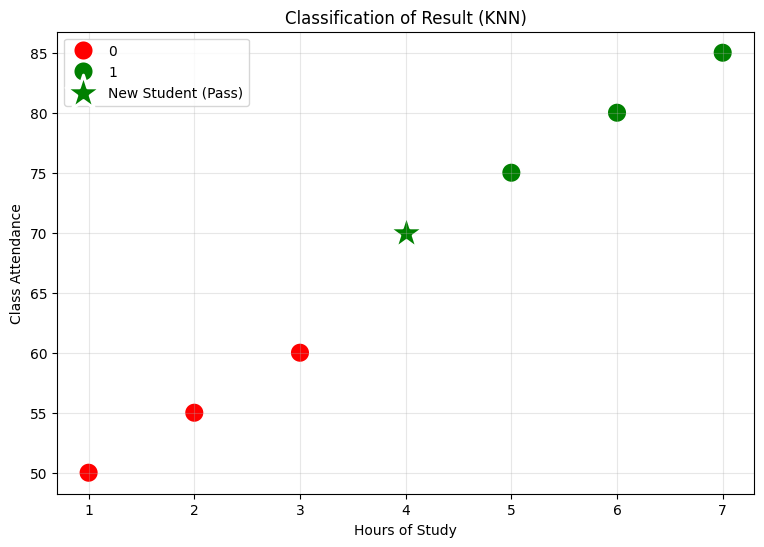

In [72]:
distances, indices = model.named_steps['kneighborsclassifier'].kneighbors(new_X_scaled)
print("Nearest Neighbors:")
for i in range(k):
    index = indices[0][i]
    distance = distances[0][i]
    print(f"Neighbor {i+1}: X = {X[index]}, Class = {y[index]}, Distance = {distance:.4f}")
print("\n")

plt.figure(figsize=(9, 6))
sns.scatterplot(
    x = X[:, 0],
    y = X[:, 1],
    hue = y,
    palette = {0: "red", 1: "green"},
    marker = "o",
    s=200,
    edgecolor="w"
)

sns.scatterplot(
    x = new_X[:,0],
    y = new_X[:,1],
    color = 'green' if new_pred[0] else 'red',
    marker = "*",
    s=700,
    label = f'New Student (Pass)'
)

plt.xlabel("Hours of Study")
plt.ylabel("Class Attendance")
plt.title("Classification of Result (KNN)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()